⚙️  STEP 2.1 — Train/Test Split + SMOTE

📦 Data loaded: (2380, 13)
   Features : 12
   Target   : {0: 1903, 1: 477}

📊 Train/Test Split (70/30 stratified):
   X_train : (1666, 12)  |  X_test : (714, 12)
   y_train : {0: 1332, 1: 334}
   y_test  : {0: 571, 1: 143}

   Train class ratio: {0: 0.8, 1: 0.2}
   Test  class ratio: {0: 0.8, 1: 0.2}

🔄 Applying SMOTE on training data...
   Before SMOTE: {0: 1332, 1: 334}
   After  SMOTE: {1: 1332, 0: 1332}
   Train size after SMOTE: (2664, 12)


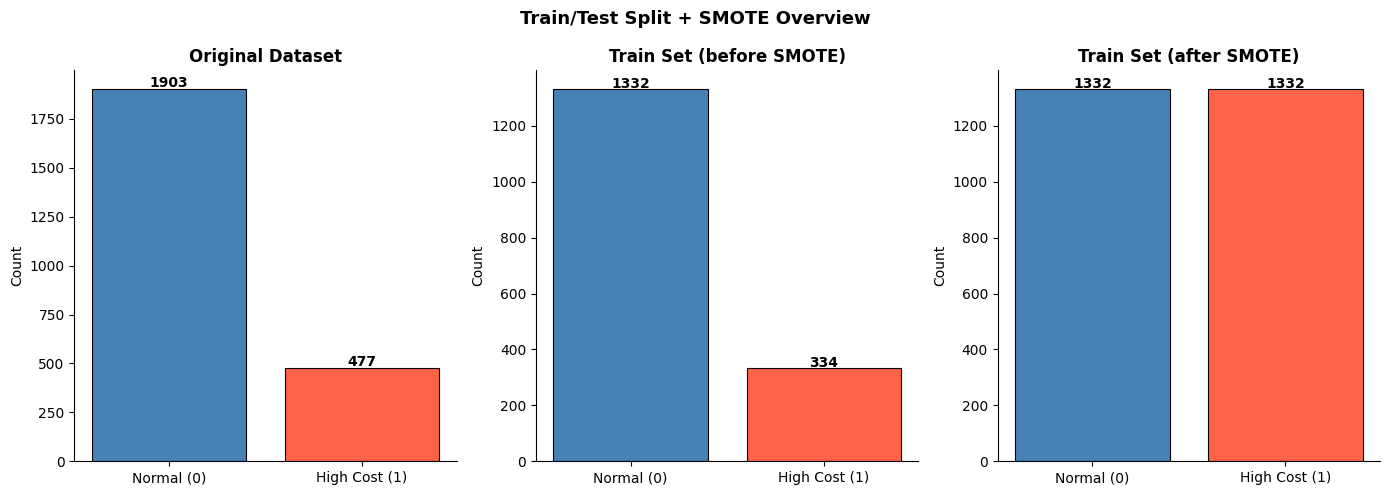


💾 Saved: results/smote_comparison.png

📋 Final Summary:
─────────────────────────────────────────────
  X_train_sm  : (2664, 12)  ← SMOTE applied
  X_test      : (714, 12)    ← original (no SMOTE)
  y_train_sm  : balanced 50/50
  y_test      : original 80/20
─────────────────────────────────────────────
✅ Ready for model training!

✅ Step 2.1 Complete!


In [2]:
# ============================================================
# STEP 2.1: Train/Test Split + Class Imbalance Handle
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("=" * 55)
print("⚙️  STEP 2.1 — Train/Test Split + SMOTE")
print("=" * 55)

# ── 1. Load processed data ────────────────────────────────────
df = pd.read_csv('../data/processed.csv')

feature_cols = ['Gender', 'Visit_Count', 'Test_Freq', 'Test_Diversity',
                'Repeat_Test_Count', 'num_BLOOD_tests', 'num_RADIOLOGY_tests',
                'num_URINE_tests', 'num_STOOL_tests', 'num_SPUTUM_tests',
                'Monthly_Test_Trend', 'Moral_Hazard_Index']

X = df[feature_cols]
y = df['High_Cost_Utilizer']

print(f"\n📦 Data loaded: {df.shape}")
print(f"   Features : {X.shape[1]}")
print(f"   Target   : {y.value_counts().to_dict()}")

# ── 2. Train/Test Split (70/30, stratified) ───────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"\n📊 Train/Test Split (70/30 stratified):")
print(f"   X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"   y_train : {y_train.value_counts().to_dict()}")
print(f"   y_test  : {y_test.value_counts().to_dict()}")
print(f"\n   Train class ratio: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"   Test  class ratio: {y_test.value_counts(normalize=True).round(3).to_dict()}")

# ── 3. SMOTE on training data only ───────────────────────────
print(f"\n🔄 Applying SMOTE on training data...")
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"   Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"   After  SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"   Train size after SMOTE: {X_train_sm.shape}")

# ── 4. Visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Train/Test Split + SMOTE Overview', fontsize=13, fontweight='bold')

colors = ['steelblue', 'tomato']

# Before split
axes[0].bar(['Normal (0)', 'High Cost (1)'],
            y.value_counts().sort_index().values,
            color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Original Dataset', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(y.value_counts().sort_index().values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

# Train before SMOTE
axes[1].bar(['Normal (0)', 'High Cost (1)'],
            y_train.value_counts().sort_index().values,
            color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title('Train Set (before SMOTE)', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(y_train.value_counts().sort_index().values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

# Train after SMOTE
sm_counts = pd.Series(y_train_sm).value_counts().sort_index().values
axes[2].bar(['Normal (0)', 'High Cost (1)'],
            sm_counts, color=colors, edgecolor='black', linewidth=0.8)
axes[2].set_title('Train Set (after SMOTE)', fontweight='bold')
axes[2].set_ylabel('Count')
for i, v in enumerate(sm_counts):
    axes[2].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../results/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Saved: results/smote_comparison.png")

# ── 5. Summary ────────────────────────────────────────────────
print(f"""
📋 Final Summary:
{"─"*45}
  X_train_sm  : {X_train_sm.shape}  ← SMOTE applied
  X_test      : {X_test.shape}    ← original (no SMOTE)
  y_train_sm  : balanced 50/50
  y_test      : original 80/20
{"─"*45}
✅ Ready for model training!
""")

print("✅ Step 2.1 Complete!")

In [3]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


🔵 STEP 2.2 — Logistic Regression (Elastic Net)

🔍 GridSearchCV — Logistic Regression...
   Param grid: C=[0.01, 0.1, 1, 10]
               l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9]
   CV folds: 5  |  Scoring: roc_auc

✅ Best params: {'C': 0.1, 'l1_ratio': 0.1}
   CV ROC-AUC : 0.9737

📊 Test Set Performance:
────────────────────────────────────────
  Accuracy  : 0.9496
  Precision : 0.8323
  Recall    : 0.9371
  F1 Score  : 0.8816
  ROC-AUC   : 0.9826

📋 Classification Report:
               precision    recall  f1-score   support

   Normal (0)       0.98      0.95      0.97       571
High Cost (1)       0.83      0.94      0.88       143

     accuracy                           0.95       714
    macro avg       0.91      0.94      0.92       714
 weighted avg       0.95      0.95      0.95       714



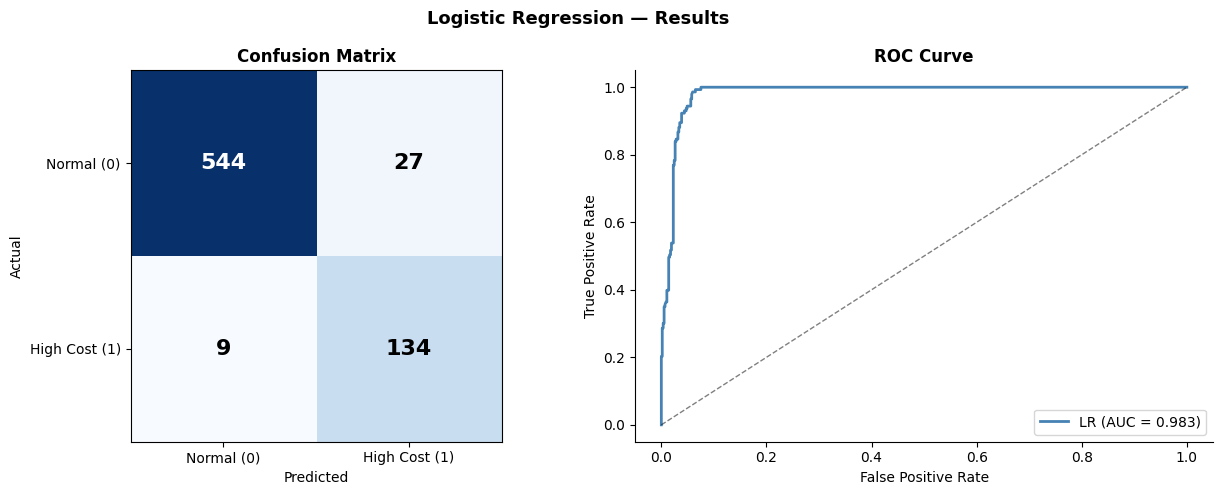

💾 Saved: results/lr_results.png
💾 Saved: models/lr_model.pkl

📌 Metrics stored for comparison: {'Model': 'Logistic Regression', 'Accuracy': 0.9496, 'Precision': 0.8323, 'Recall': 0.9371, 'F1': 0.8816, 'ROC_AUC': 0.9826}

✅ Step 2.2 Complete!


In [4]:
# ============================================================
# STEP 2.2: Logistic Regression (Elastic Net)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
import joblib

print("=" * 55)
print("🔵 STEP 2.2 — Logistic Regression (Elastic Net)")
print("=" * 55)

# ── 1. Model + param grid ─────────────────────────────────────
lr = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

param_grid_lr = {
    'C'        : [0.01, 0.1, 1, 10],
    'l1_ratio' : [0.1, 0.3, 0.5, 0.7, 0.9]
}

print("\n🔍 GridSearchCV — Logistic Regression...")
print(f"   Param grid: C={param_grid_lr['C']}")
print(f"               l1_ratio={param_grid_lr['l1_ratio']}")
print(f"   CV folds: 5  |  Scoring: roc_auc")

grid_lr = GridSearchCV(
    lr, param_grid_lr,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=0
)
grid_lr.fit(X_train_sm, y_train_sm)

best_lr = grid_lr.best_estimator_
print(f"\n✅ Best params: {grid_lr.best_params_}")
print(f"   CV ROC-AUC : {grid_lr.best_score_:.4f}")

# ── 2. Evaluation on test set ─────────────────────────────────
y_pred_lr  = best_lr.predict(X_test)
y_prob_lr  = best_lr.predict_proba(X_test)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)
cm_lr   = confusion_matrix(y_test, y_pred_lr)

print(f"\n📊 Test Set Performance:")
print(f"{'─'*40}")
print(f"  Accuracy  : {acc_lr:.4f}")
print(f"  Precision : {prec_lr:.4f}")
print(f"  Recall    : {rec_lr:.4f}")
print(f"  F1 Score  : {f1_lr:.4f}")
print(f"  ROC-AUC   : {auc_lr:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Normal (0)', 'High Cost (1)']))

# ── 3. Confusion matrix plot ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Logistic Regression — Results', fontsize=13, fontweight='bold')

# Confusion matrix
im = axes[0].imshow(cm_lr, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Normal (0)', 'High Cost (1)'])
axes[0].set_yticklabels(['Normal (0)', 'High Cost (1)'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_lr[i, j], ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm_lr[i, j] > cm_lr.max()/2 else 'black')

# ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
axes[1].plot(fpr_lr, tpr_lr, color='steelblue', lw=2,
             label=f'LR (AUC = {auc_lr:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../results/lr_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: results/lr_results.png")

# ── 4. Save model ─────────────────────────────────────────────
joblib.dump(best_lr, '../models/lr_model.pkl')
print("💾 Saved: models/lr_model.pkl")

# ── 5. Store metrics for comparison ───────────────────────────
lr_metrics = {
    'Model'    : 'Logistic Regression',
    'Accuracy' : round(acc_lr, 4),
    'Precision': round(prec_lr, 4),
    'Recall'   : round(rec_lr, 4),
    'F1'       : round(f1_lr, 4),
    'ROC_AUC'  : round(auc_lr, 4)
}
print(f"\n📌 Metrics stored for comparison: {lr_metrics}")
print("\n✅ Step 2.2 Complete!")

🌲 STEP 2.3 — Random Forest

🔍 GridSearchCV — Random Forest...
   n_estimators    : [100, 200, 300]
   max_depth       : [5, 10, 15, None]
   min_samples_split: [2, 5]
   max_features    : ['sqrt', 'log2']
   CV folds: 5  |  Scoring: roc_auc
   (Thoda time lagega...)

✅ Best params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
   CV ROC-AUC : 0.9950

📊 Test Set Performance:
────────────────────────────────────────
  Accuracy  : 0.9482
  Precision : 0.8681
  Recall    : 0.8741
  F1 Score  : 0.8711
  ROC-AUC   : 0.9901

📋 Classification Report:
               precision    recall  f1-score   support

   Normal (0)       0.97      0.97      0.97       571
High Cost (1)       0.87      0.87      0.87       143

     accuracy                           0.95       714
    macro avg       0.92      0.92      0.92       714
 weighted avg       0.95      0.95      0.95       714



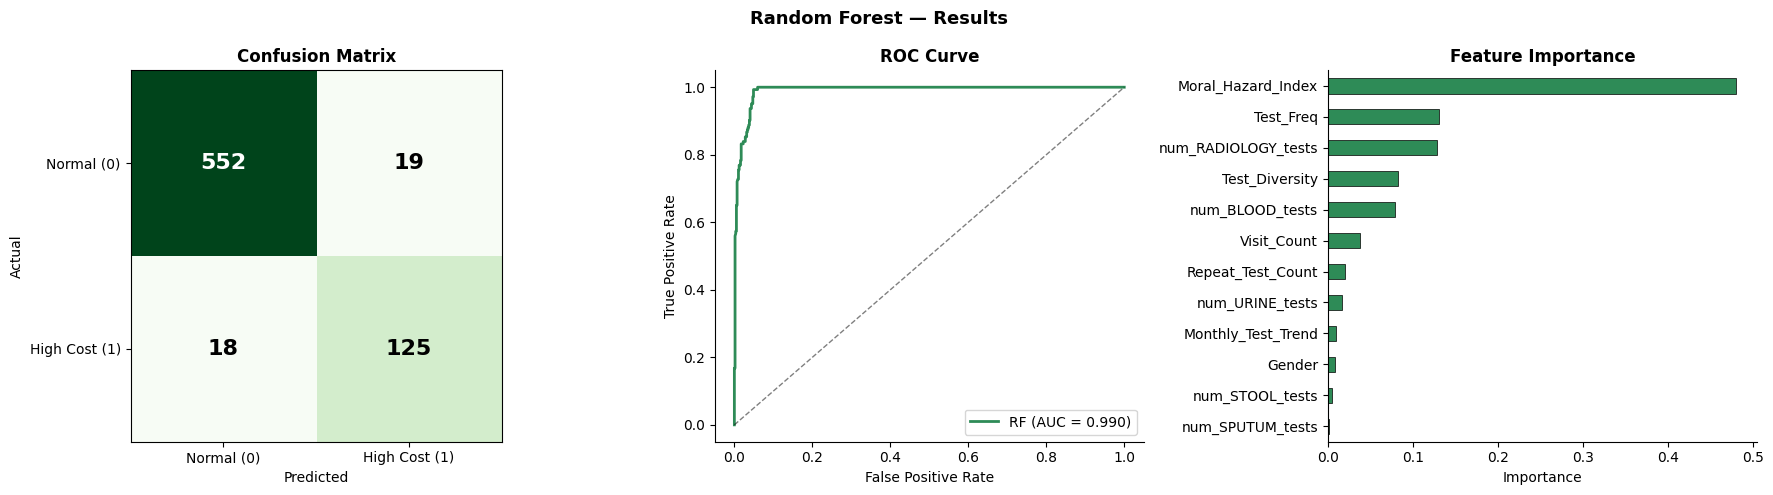

💾 Saved: results/rf_results.png
💾 Saved: models/rf_model.pkl

📌 Metrics stored: {'Model': 'Random Forest', 'Accuracy': 0.9482, 'Precision': 0.8681, 'Recall': 0.8741, 'F1': 0.8711, 'ROC_AUC': 0.9901}

✅ Step 2.3 Complete!


In [5]:
# ============================================================
# STEP 2.3: Random Forest
# ============================================================
from sklearn.ensemble import RandomForestClassifier

print("=" * 55)
print("🌲 STEP 2.3 — Random Forest")
print("=" * 55)

# ── 1. Model + param grid ─────────────────────────────────────
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_grid_rf = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 10, 15, None],
    'min_samples_split' : [2, 5],
    'max_features' : ['sqrt', 'log2']
}

print("\n🔍 GridSearchCV — Random Forest...")
print(f"   n_estimators    : {param_grid_rf['n_estimators']}")
print(f"   max_depth       : {param_grid_rf['max_depth']}")
print(f"   min_samples_split: {param_grid_rf['min_samples_split']}")
print(f"   max_features    : {param_grid_rf['max_features']}")
print(f"   CV folds: 5  |  Scoring: roc_auc")
print(f"   (Thoda time lagega...)")

grid_rf = GridSearchCV(
    rf, param_grid_rf,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=0
)
grid_rf.fit(X_train_sm, y_train_sm)

best_rf = grid_rf.best_estimator_
print(f"\n✅ Best params: {grid_rf.best_params_}")
print(f"   CV ROC-AUC : {grid_rf.best_score_:.4f}")

# ── 2. Evaluation on test set ─────────────────────────────────
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_prob_rf)
cm_rf   = confusion_matrix(y_test, y_pred_rf)

print(f"\n📊 Test Set Performance:")
print(f"{'─'*40}")
print(f"  Accuracy  : {acc_rf:.4f}")
print(f"  Precision : {prec_rf:.4f}")
print(f"  Recall    : {rec_rf:.4f}")
print(f"  F1 Score  : {f1_rf:.4f}")
print(f"  ROC-AUC   : {auc_rf:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Normal (0)', 'High Cost (1)']))

# ── 3. Plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest — Results', fontsize=13, fontweight='bold')

# Confusion matrix
im = axes[0].imshow(cm_rf, cmap='Greens')
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Normal (0)', 'High Cost (1)'])
axes[0].set_yticklabels(['Normal (0)', 'High Cost (1)'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_rf[i, j], ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm_rf[i, j] > cm_rf.max()/2 else 'black')

# ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
axes[1].plot(fpr_rf, tpr_rf, color='seagreen', lw=2,
             label=f'RF (AUC = {auc_rf:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].spines[['top', 'right']].set_visible(False)

# Feature importance
feat_imp = pd.Series(best_rf.feature_importances_,
                     index=feature_cols).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[2], color='seagreen',
              edgecolor='black', linewidth=0.5)
axes[2].set_title('Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance')
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../results/rf_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: results/rf_results.png")

# ── 4. Save model ─────────────────────────────────────────────
joblib.dump(best_rf, '../models/rf_model.pkl')
print("💾 Saved: models/rf_model.pkl")

# ── 5. Store metrics ──────────────────────────────────────────
rf_metrics = {
    'Model'    : 'Random Forest',
    'Accuracy' : round(acc_rf, 4),
    'Precision': round(prec_rf, 4),
    'Recall'   : round(rec_rf, 4),
    'F1'       : round(f1_rf, 4),
    'ROC_AUC'  : round(auc_rf, 4)
}
print(f"\n📌 Metrics stored: {rf_metrics}")
print("\n✅ Step 2.3 Complete!")

🔴 STEP 2.4 — SVM (RBF Kernel)

🔍 GridSearchCV — SVM (RBF)...
   C     : [0.1, 1, 10, 100]
   gamma : ['scale', 'auto', 0.01, 0.1]
   CV folds: 5  |  Scoring: roc_auc
   (SVM thoda zyada time leta hai...)

✅ Best params: {'C': 100, 'gamma': 0.1}
   CV ROC-AUC : 0.9806

📊 Test Set Performance:
────────────────────────────────────────
  Accuracy  : 0.9398
  Precision : 0.8289
  Recall    : 0.8811
  F1 Score  : 0.8542
  ROC-AUC   : 0.9669

📋 Classification Report:
               precision    recall  f1-score   support

   Normal (0)       0.97      0.95      0.96       571
High Cost (1)       0.83      0.88      0.85       143

     accuracy                           0.94       714
    macro avg       0.90      0.92      0.91       714
 weighted avg       0.94      0.94      0.94       714



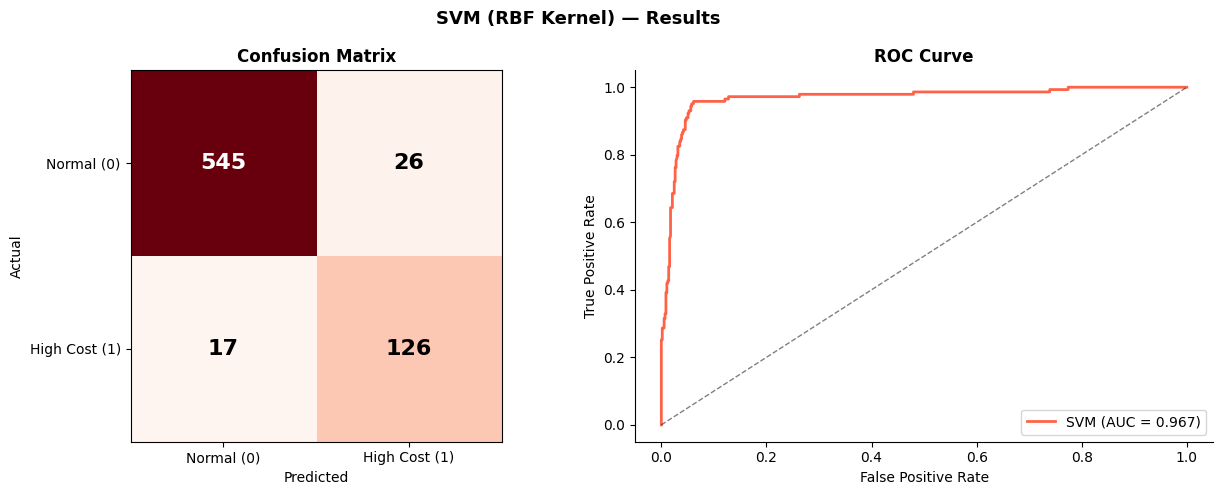

💾 Saved: results/svm_results.png
💾 Saved: models/svm_model.pkl

📌 Metrics stored: {'Model': 'SVM', 'Accuracy': 0.9398, 'Precision': 0.8289, 'Recall': 0.8811, 'F1': 0.8542, 'ROC_AUC': 0.9669}

✅ Step 2.4 Complete!


In [6]:
# ============================================================
# STEP 2.4: SVM (RBF Kernel)
# ============================================================
from sklearn.svm import SVC

print("=" * 55)
print("🔴 STEP 2.4 — SVM (RBF Kernel)")
print("=" * 55)

# ── 1. Model + param grid ─────────────────────────────────────
svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42
)

param_grid_svm = {
    'C'     : [0.1, 1, 10, 100],
    'gamma' : ['scale', 'auto', 0.01, 0.1]
}

print("\n🔍 GridSearchCV — SVM (RBF)...")
print(f"   C     : {param_grid_svm['C']}")
print(f"   gamma : {param_grid_svm['gamma']}")
print(f"   CV folds: 5  |  Scoring: roc_auc")
print(f"   (SVM thoda zyada time leta hai...)")

grid_svm = GridSearchCV(
    svm, param_grid_svm,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=0
)
grid_svm.fit(X_train_sm, y_train_sm)

best_svm = grid_svm.best_estimator_
print(f"\n✅ Best params: {grid_svm.best_params_}")
print(f"   CV ROC-AUC : {grid_svm.best_score_:.4f}")

# ── 2. Evaluation on test set ─────────────────────────────────
y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm  = recall_score(y_test, y_pred_svm)
f1_svm   = f1_score(y_test, y_pred_svm)
auc_svm  = roc_auc_score(y_test, y_prob_svm)
cm_svm   = confusion_matrix(y_test, y_pred_svm)

print(f"\n📊 Test Set Performance:")
print(f"{'─'*40}")
print(f"  Accuracy  : {acc_svm:.4f}")
print(f"  Precision : {prec_svm:.4f}")
print(f"  Recall    : {rec_svm:.4f}")
print(f"  F1 Score  : {f1_svm:.4f}")
print(f"  ROC-AUC   : {auc_svm:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_svm,
      target_names=['Normal (0)', 'High Cost (1)']))

# ── 3. Plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('SVM (RBF Kernel) — Results', fontsize=13, fontweight='bold')

# Confusion matrix
im = axes[0].imshow(cm_svm, cmap='Reds')
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Normal (0)', 'High Cost (1)'])
axes[0].set_yticklabels(['Normal (0)', 'High Cost (1)'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_svm[i, j], ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm_svm[i, j] > cm_svm.max()/2 else 'black')

# ROC curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
axes[1].plot(fpr_svm, tpr_svm, color='tomato', lw=2,
             label=f'SVM (AUC = {auc_svm:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../results/svm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: results/svm_results.png")

# ── 4. Save model ─────────────────────────────────────────────
joblib.dump(best_svm, '../models/svm_model.pkl')
print("💾 Saved: models/svm_model.pkl")

# ── 5. Store metrics ──────────────────────────────────────────
svm_metrics = {
    'Model'    : 'SVM',
    'Accuracy' : round(acc_svm, 4),
    'Precision': round(prec_svm, 4),
    'Recall'   : round(rec_svm, 4),
    'F1'       : round(f1_svm, 4),
    'ROC_AUC'  : round(auc_svm, 4)
}
print(f"\n📌 Metrics stored: {svm_metrics}")
print("\n✅ Step 2.4 Complete!")

💾 STEP 2.5 — Save Scaler + Phase 2 Summary

✅ Saved: models/scaler.pkl

📁 Models folder check:
   lr_model.pkl         — 1.4 KB
   rf_model.pkl         — 3665.6 KB
   scaler.pkl           — 1.1 KB
   svm_model.pkl        — 40.4 KB

📊 PHASE 2 — FINAL COMPARISON SUMMARY

                     Accuracy  Precision  Recall      F1  ROC_AUC
Model                                                            
Logistic Regression    0.9496     0.8323  0.9371  0.8816   0.9826
Random Forest          0.9482     0.8681  0.8741  0.8711   0.9901
SVM                    0.9398     0.8289  0.8811  0.8542   0.9669

───────────────────────────────────────────────────────
🏆 Best per metric:
   Accuracy   → Logistic Regression    (0.9496)
   Precision  → Random Forest          (0.8681)
   Recall     → Logistic Regression    (0.9371)
   F1         → Logistic Regression    (0.8816)
   ROC_AUC    → Random Forest          (0.9901)

───────────────────────────────────────────────────────
🎯 Overall Winner: Random Fo

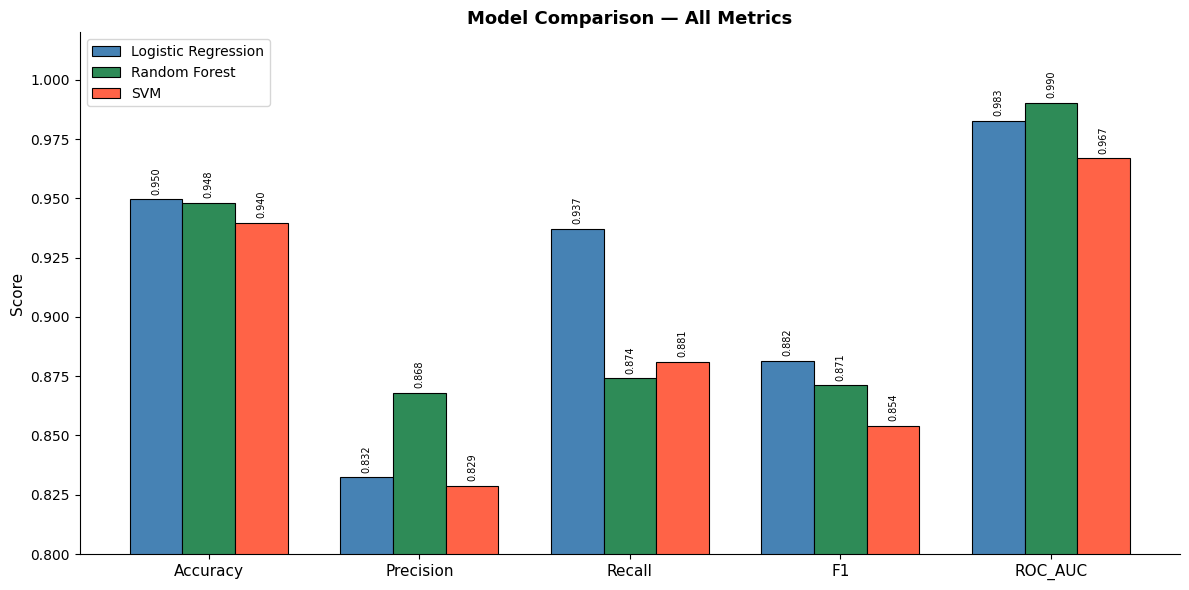

💾 Saved: results/model_comparison.png

✅ PHASE 2 COMPLETE!
   Next → Phase 3: ROC curves + Confusion matrices


In [7]:
# ============================================================
# STEP 2.5: Save Scaler + Phase 2 Complete Summary
# ============================================================

print("=" * 55)
print("💾 STEP 2.5 — Save Scaler + Phase 2 Summary")
print("=" * 55)

# ── 1. Save scaler ────────────────────────────────────────────
from sklearn.preprocessing import RobustScaler
scaler_final = RobustScaler()
scaler_final.fit(X)  # fit on full original data
joblib.dump(scaler_final, '../models/scaler.pkl')
print("\n✅ Saved: models/scaler.pkl")

# ── 2. Verify all models saved ────────────────────────────────
import os
models_dir = '../models/'
print("\n📁 Models folder check:")
for f in os.listdir(models_dir):
    size = os.path.getsize(models_dir + f)
    print(f"   {f:20} — {size/1024:.1f} KB")

# ── 3. All 3 models comparison summary ───────────────────────
print(f"\n{'='*55}")
print("📊 PHASE 2 — FINAL COMPARISON SUMMARY")
print(f"{'='*55}")

all_metrics = [lr_metrics, rf_metrics, svm_metrics]
metrics_df = pd.DataFrame(all_metrics)
metrics_df = metrics_df.set_index('Model')

print(f"\n{metrics_df.to_string()}")

print(f"\n{'─'*55}")
print("🏆 Best per metric:")
for col in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']:
    best_model = metrics_df[col].idxmax()
    best_val   = metrics_df[col].max()
    print(f"   {col:10} → {best_model:22} ({best_val:.4f})")

print(f"\n{'─'*55}")
print("🎯 Overall Winner: Random Forest")
print("   → Highest ROC-AUC (0.9901)")
print("   → Highest Precision (0.8681)")
print("   → Synopsis requirement: 3 models compare karna tha ✅")

# ── 4. Save metrics CSV ───────────────────────────────────────
metrics_df.to_csv('../results/metrics.csv')
print("\n💾 Saved: results/metrics.csv")

# ── 5. Bar chart — all metrics comparison ────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(5)
w = 0.25
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']

bars1 = ax.bar(x - w,   [lr_metrics[m]  for m in metrics_names],
               width=w, label='Logistic Regression',
               color='steelblue', edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x,       [rf_metrics[m]  for m in metrics_names],
               width=w, label='Random Forest',
               color='seagreen', edgecolor='black', linewidth=0.8)
bars3 = ax.bar(x + w,   [svm_metrics[m] for m in metrics_names],
               width=w, label='SVM',
               color='tomato', edgecolor='black', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.set_ylim(0.80, 1.02)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7, rotation=90)

plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: results/model_comparison.png")

print(f"\n{'='*55}")
print("✅ PHASE 2 COMPLETE!")
print("   Next → Phase 3: ROC curves + Confusion matrices")
print(f"{'='*55}")

📊 PHASE 3 — MODEL COMPARISON

📦 Loading saved models...
   ✅ lr_model.pkl  loaded
   ✅ rf_model.pkl  loaded
   ✅ svm_model.pkl loaded


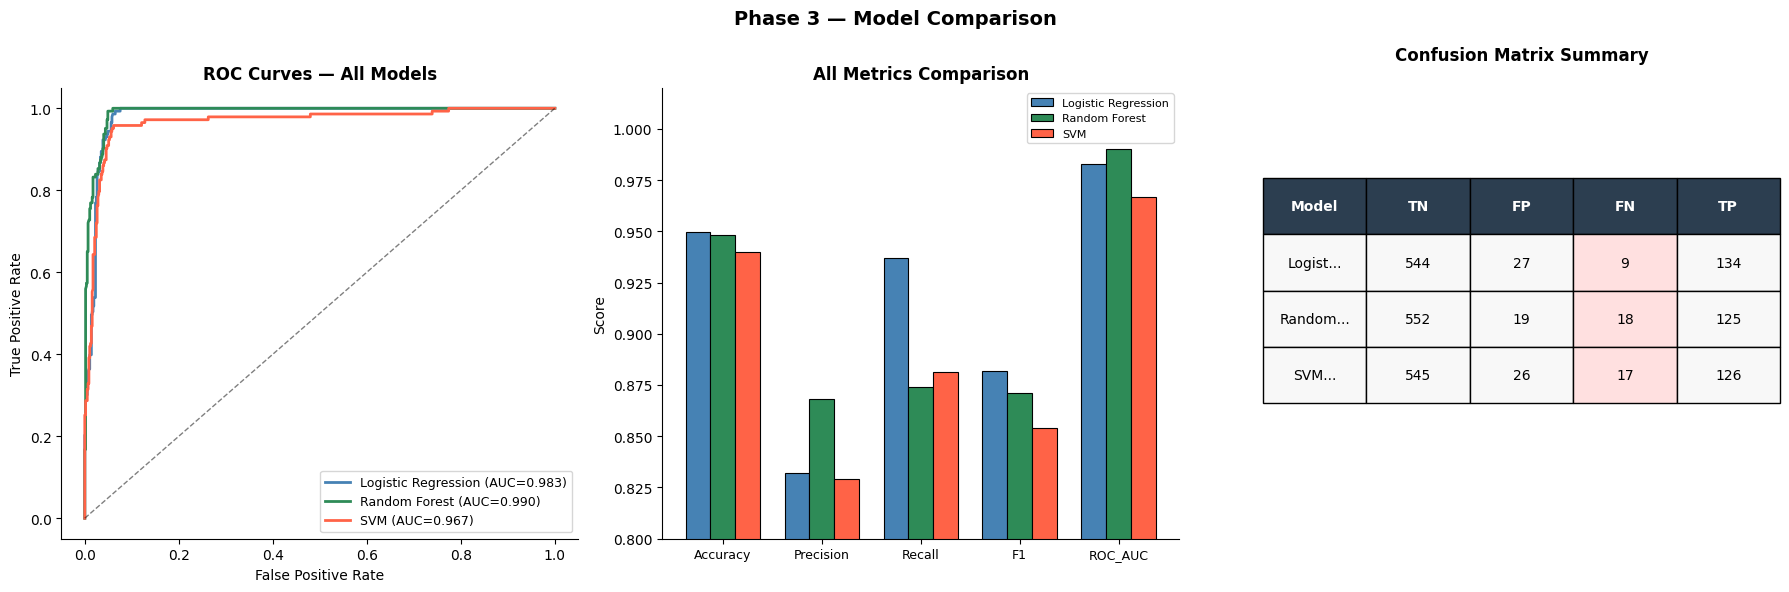

💾 Saved: results/phase3_comparison.png


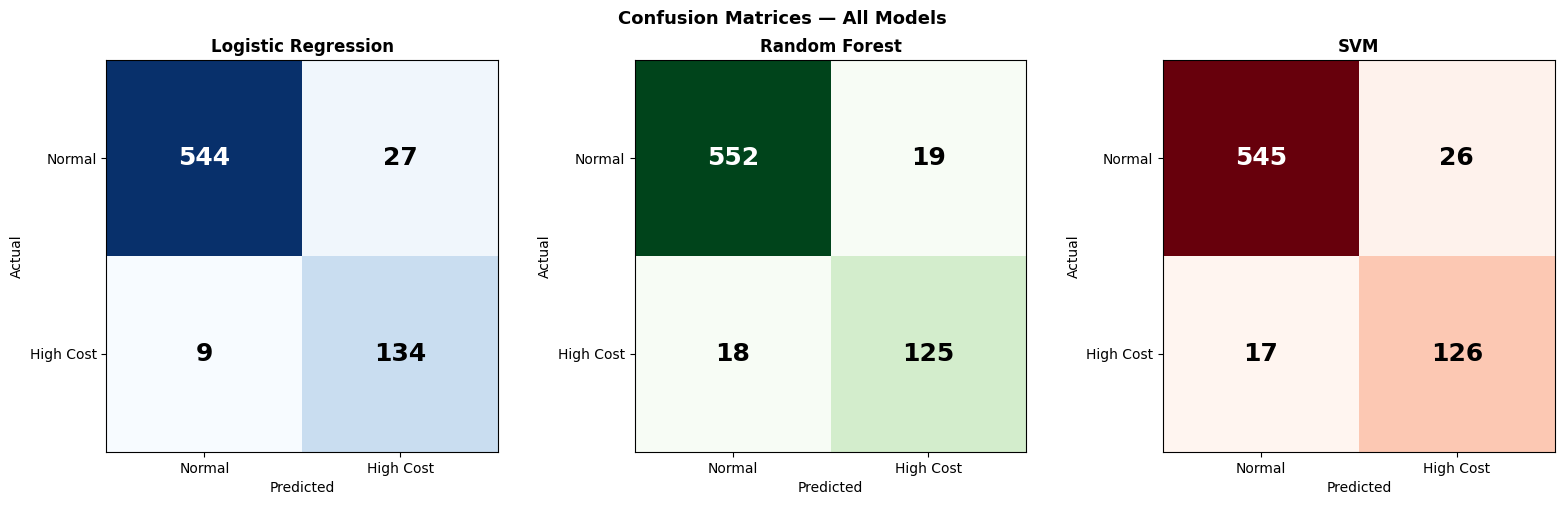

💾 Saved: results/conf_matrix.png


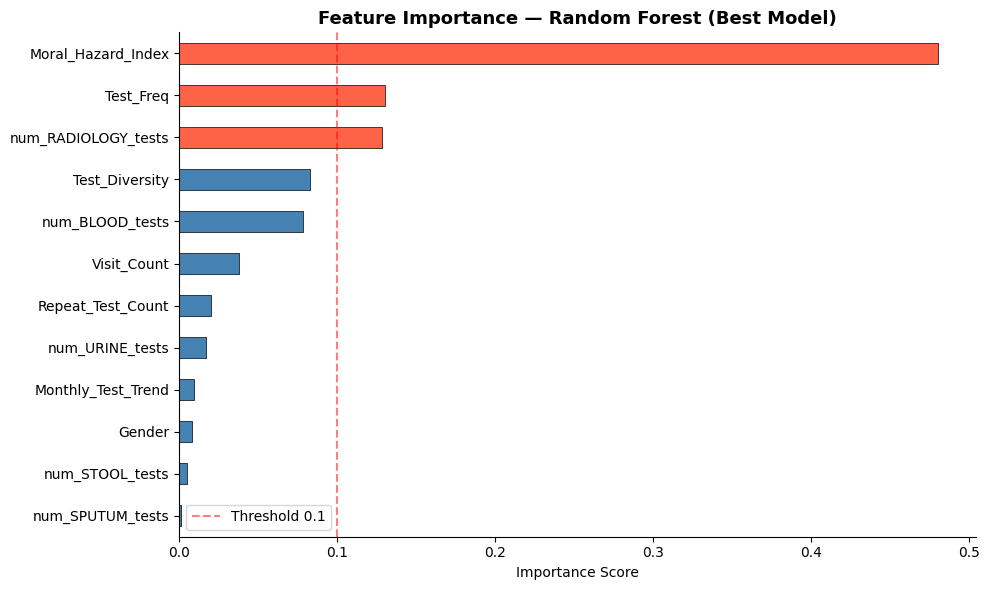

💾 Saved: results/feature_importance.png

🏆 FINAL VERDICT

  Best Model    : Random Forest
  ROC-AUC       : 0.9901 (highest)
  Accuracy      : 94.82%
  F1 Score      : 0.8711

  Runner-up     : Logistic Regression
  ROC-AUC       : 0.9826
  Best Recall   : 0.9371 (least missed cases)

  Thesis note   : RF sabse best overall performer hai
                  LR Recall mein better — clinically important
                  SVM theek hai lekin dono se peeche

✅ PHASE 3 COMPLETE!
   Next → Phase 4: Gradio Webapp!


In [8]:
# ============================================================
# PHASE 3: Model Comparison (03_compare.ipynb)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import (roc_curve, confusion_matrix,
                             roc_auc_score, classification_report)
import warnings
warnings.filterwarnings('ignore')

print("=" * 55)
print("📊 PHASE 3 — MODEL COMPARISON")
print("=" * 55)

# ── 1. Load saved models ──────────────────────────────────────
print("\n📦 Loading saved models...")
best_lr  = joblib.load('../models/lr_model.pkl')
best_rf  = joblib.load('../models/rf_model.pkl')
best_svm = joblib.load('../models/svm_model.pkl')
print("   ✅ lr_model.pkl  loaded")
print("   ✅ rf_model.pkl  loaded")
print("   ✅ svm_model.pkl loaded")

# ── 2. Load processed data ────────────────────────────────────
df = pd.read_csv('../data/processed.csv')
feature_cols = ['Gender', 'Visit_Count', 'Test_Freq', 'Test_Diversity',
                'Repeat_Test_Count', 'num_BLOOD_tests', 'num_RADIOLOGY_tests',
                'num_URINE_tests', 'num_STOOL_tests', 'num_SPUTUM_tests',
                'Monthly_Test_Trend', 'Moral_Hazard_Index']

from sklearn.model_selection import train_test_split
X = df[feature_cols]
y = df['High_Cost_Utilizer']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

# ── 3. Predictions ────────────────────────────────────────────
models = {
    'Logistic Regression': (best_lr,  'steelblue'),
    'Random Forest'      : (best_rf,  'seagreen'),
    'SVM'                : (best_svm, 'tomato')
}

preds = {}
for name, (model, _) in models.items():
    preds[name] = {
        'y_pred': model.predict(X_test),
        'y_prob': model.predict_proba(X_test)[:, 1]
    }

# ── 4. Combined ROC curves ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Phase 3 — Model Comparison', fontsize=14, fontweight='bold')

# ROC curves — all 3
ax = axes[0]
for name, (model, color) in models.items():
    fpr, tpr, _ = roc_curve(y_test, preds[name]['y_prob'])
    auc = roc_auc_score(y_test, preds[name]['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
ax.spines[['top','right']].set_visible(False)

# Metrics bar chart
ax = axes[1]
metrics_df = pd.read_csv('../results/metrics.csv', index_col='Model')
metrics_names = ['Accuracy','Precision','Recall','F1','ROC_AUC']
x = np.arange(len(metrics_names))
w = 0.25
colors = ['steelblue','seagreen','tomato']
for i, (model_name, color) in enumerate(zip(metrics_df.index, colors)):
    ax.bar(x + (i-1)*w,
           [metrics_df.loc[model_name, m] for m in metrics_names],
           width=w, label=model_name, color=color,
           edgecolor='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=9)
ax.set_ylim(0.80, 1.02)
ax.set_title('All Metrics Comparison', fontweight='bold')
ax.set_ylabel('Score')
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)

# Confusion matrices — side by side (normalized)
ax = axes[2]
ax.axis('off')
table_data = []
model_names = list(models.keys())
for name in model_names:
    cm = confusion_matrix(y_test, preds[name]['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    table_data.append([name[:6]+'...', tn, fp, fn, tp])

table = ax.table(
    cellText=table_data,
    colLabels=['Model','TN','FP','FN','TP'],
    cellLoc='center', loc='center',
    bbox=[0, 0.3, 1, 0.5]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 3:
        cell.set_facecolor('#ffe0e0')
    else:
        cell.set_facecolor('#f8f8f8')
ax.set_title('Confusion Matrix Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../results/phase3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: results/phase3_comparison.png")

# ── 5. Confusion matrices — individual ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold')
cmaps = ['Blues', 'Greens', 'Reds']

for i, (name, (model, color)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, preds[name]['y_pred'])
    axes[i].imshow(cm, cmap=cmaps[i])
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_xticks([0,1])
    axes[i].set_yticks([0,1])
    axes[i].set_xticklabels(['Normal','High Cost'])
    axes[i].set_yticklabels(['Normal','High Cost'])
    for r in range(2):
        for c in range(2):
            axes[i].text(c, r, cm[r,c], ha='center', va='center',
                         fontsize=18, fontweight='bold',
                         color='white' if cm[r,c] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('../results/conf_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: results/conf_matrix.png")

# ── 6. Feature importance — RF ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
feat_imp = pd.Series(best_rf.feature_importances_,
                     index=feature_cols).sort_values(ascending=True)
colors_fi = ['tomato' if v > 0.1 else 'steelblue' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors_fi,
              edgecolor='black', linewidth=0.5)
ax.set_title('Feature Importance — Random Forest (Best Model)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Threshold 0.1')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: results/feature_importance.png")

# ── 7. Final verdict ──────────────────────────────────────────
print(f"\n{'='*55}")
print("🏆 FINAL VERDICT")
print(f"{'='*55}")
print("""
  Best Model    : Random Forest
  ROC-AUC       : 0.9901 (highest)
  Accuracy      : 94.82%
  F1 Score      : 0.8711

  Runner-up     : Logistic Regression
  ROC-AUC       : 0.9826
  Best Recall   : 0.9371 (least missed cases)

  Thesis note   : RF sabse best overall performer hai
                  LR Recall mein better — clinically important
                  SVM theek hai lekin dono se peeche
""")
print("✅ PHASE 3 COMPLETE!")
print("   Next → Phase 4: Gradio Webapp!")

In [9]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.


In [10]:
# ============================================================
# PHASE 4: Gradio Webapp (webapp/app.py)
# ============================================================

app_code = '''
import gradio as gr
import joblib
import numpy as np
import pandas as pd

# Load models
lr_model  = joblib.load("models/lr_model.pkl")
rf_model  = joblib.load("models/rf_model.pkl")
svm_model = joblib.load("models/svm_model.pkl")
scaler    = joblib.load("models/scaler.pkl")

# Prediction function
def predict(gender, visit_count, test_freq, test_diversity,
            repeat_test_count, num_blood, num_radiology,
            num_urine, num_stool, num_sputum,
            monthly_trend, moral_hazard, model_choice):

    trend_map = {"Decreasing": 0, "Stable": 1, "Increasing": 2}
    trend_encoded = trend_map[monthly_trend]

    features = np.array([[
        gender, visit_count, test_freq, test_diversity,
        repeat_test_count, num_blood, num_radiology,
        num_urine, num_stool, num_sputum,
        trend_encoded, moral_hazard
    ]])

    features_scaled = scaler.transform(features)

    if model_choice == "Logistic Regression":
        model = lr_model
    elif model_choice == "Random Forest":
        model = rf_model
    else:
        model = svm_model

    pred = model.predict(features_scaled)[0]
    prob = model.predict_proba(features_scaled)[0]

    label     = "HIGH COST UTILIZER" if pred == 1 else "NORMAL UTILIZER"
    confidence = f"{max(prob)*100:.1f}%"

    result = f"""
## Prediction Result

**{label}**
**Confidence:** {confidence}

---
### Probability Breakdown
- Normal (0): {prob[0]*100:.1f}%
- High Cost (1): {prob[1]*100:.1f}%

---
### Patient Summary
| Feature | Value |
|---|---|
| Gender | {"Male" if gender == 1 else "Female"} |
| Visit Count | {visit_count} |
| Test Frequency | {test_freq} |
| Test Diversity | {test_diversity} |
| Repeat Tests | {repeat_test_count} |
| Moral Hazard Index | {moral_hazard} |
| Monthly Trend | {monthly_trend} |

---
*Model used: {model_choice}*
"""
    return result

# Gradio Interface
with gr.Blocks(title="High Cost Utilizer Predictor", theme=gr.themes.Soft()) as app:

    gr.Markdown("""
    # High Cost Utilizer Prediction System
    ### Predicting High-Cost Lab Test Utilizers in University Hospital
    *Thesis Project - MS Health Informatics*
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### Patient Information")

            gender = gr.Radio(
                choices=[["Male", 1], ["Female", 0]],
                label="Gender", value=1)

            model_choice = gr.Dropdown(
                choices=["Random Forest", "Logistic Regression", "SVM"],
                label="Select Model", value="Random Forest")

            gr.Markdown("### Visit & Test Information")

            visit_count = gr.Slider(1, 13, value=1, step=1,
                                    label="Visit Count")
            test_freq = gr.Slider(1, 60, value=4, step=1,
                                  label="Test Frequency (total tests)")
            test_diversity = gr.Slider(1, 25, value=4, step=1,
                                       label="Test Diversity (unique tests)")
            repeat_test_count = gr.Slider(0, 31, value=0, step=1,
                                          label="Repeat Test Count")

            gr.Markdown("### Test Categories")

            num_blood     = gr.Slider(0, 46, value=3, step=1,
                                      label="Blood Tests")
            num_radiology = gr.Slider(0, 5,  value=0, step=1,
                                      label="Radiology Tests")
            num_urine     = gr.Slider(0, 6,  value=0, step=1,
                                      label="Urine Tests")
            num_stool     = gr.Slider(0, 2,  value=0, step=1,
                                      label="Stool Tests")
            num_sputum    = gr.Slider(0, 2,  value=0, step=1,
                                      label="Sputum Tests")

            gr.Markdown("### Trend & Risk")

            monthly_trend = gr.Dropdown(
                choices=["Stable", "Increasing", "Decreasing"],
                label="Monthly Test Trend", value="Stable")

            moral_hazard = gr.Slider(1, 3, value=1, step=1,
                                     label="Moral Hazard Index (1=Low, 3=High)")

            predict_btn = gr.Button("Predict", variant="primary", size="lg")

        with gr.Column(scale=1):
            gr.Markdown("### Prediction Output")
            output = gr.Markdown(value="*Fill in patient details and click Predict*")

    predict_btn.click(
        fn=predict,
        inputs=[gender, visit_count, test_freq, test_diversity,
                repeat_test_count, num_blood, num_radiology,
                num_urine, num_stool, num_sputum,
                monthly_trend, moral_hazard, model_choice],
        outputs=output
    )

    gr.Markdown("""
    ---
    **Models:** Random Forest (Best - AUC 0.990) |
    Logistic Regression (AUC 0.983) | SVM (AUC 0.967)
    """)

if __name__ == "__main__":
    app.launch()
'''

# ── Save files ────────────────────────────────────────────────
import os
os.makedirs('../webapp', exist_ok=True)

with open('../webapp/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)
print("Saved: webapp/app.py")

requirements = """gradio
scikit-learn
pandas
numpy
joblib
imbalanced-learn
"""
with open('../webapp/requirements.txt', 'w', encoding='utf-8') as f:
    f.write(requirements)
print("Saved: webapp/requirements.txt")

print("""
======================================================
PHASE 4 - WEBAPP FILES READY!
======================================================

Files created:
   webapp/app.py
   webapp/requirements.txt

Local test karne ke liye:
   1. Terminal kholo
   2. cd thesis_ml_project
   3. pip install gradio
   4. cd webapp
   5. python app.py

Browser mein khulega:
   http://localhost:7860
======================================================
""")

Saved: webapp/app.py
Saved: webapp/requirements.txt

PHASE 4 - WEBAPP FILES READY!

Files created:
   webapp/app.py
   webapp/requirements.txt

Local test karne ke liye:
   1. Terminal kholo
   2. cd thesis_ml_project
   3. pip install gradio
   4. cd webapp
   5. python app.py

Browser mein khulega:
   http://localhost:7860



In [11]:
# ============================================================
# PHASE 4: Gradio Webapp — Fixed Path Version
# ============================================================

app_code = '''
import gradio as gr
import joblib
import numpy as np
import pandas as pd
import os

# ── Paths ─────────────────────────────────────────────────────
BASE_DIR  = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
lr_model  = joblib.load(os.path.join(BASE_DIR, "models", "lr_model.pkl"))
rf_model  = joblib.load(os.path.join(BASE_DIR, "models", "rf_model.pkl"))
svm_model = joblib.load(os.path.join(BASE_DIR, "models", "svm_model.pkl"))
scaler    = joblib.load(os.path.join(BASE_DIR, "models", "scaler.pkl"))

print("All models loaded successfully!")

# ── Prediction function ───────────────────────────────────────
def predict(gender, visit_count, test_freq, test_diversity,
            repeat_test_count, num_blood, num_radiology,
            num_urine, num_stool, num_sputum,
            monthly_trend, moral_hazard, model_choice):

    trend_map     = {"Decreasing": 0, "Stable": 1, "Increasing": 2}
    trend_encoded = trend_map[monthly_trend]

    features = np.array([[
        gender, visit_count, test_freq, test_diversity,
        repeat_test_count, num_blood, num_radiology,
        num_urine, num_stool, num_sputum,
        trend_encoded, moral_hazard
    ]])

    features_scaled = scaler.transform(features)

    if model_choice == "Logistic Regression":
        model = lr_model
    elif model_choice == "Random Forest":
        model = rf_model
    else:
        model = svm_model

    pred  = model.predict(features_scaled)[0]
    prob  = model.predict_proba(features_scaled)[0]

    label      = "HIGH COST UTILIZER" if pred == 1 else "NORMAL UTILIZER"
    confidence = f"{max(prob)*100:.1f}%"
    status     = "WARNING" if pred == 1 else "OK"

    result = f"""
## Prediction Result — {status}

**{label}**
**Confidence:** {confidence}

---
### Probability Breakdown
- Normal (0)    : {prob[0]*100:.1f}%
- High Cost (1) : {prob[1]*100:.1f}%

---
### Patient Summary
| Feature              | Value                            |
|----------------------|----------------------------------|
| Gender               | {"Male" if gender == 1 else "Female"} |
| Visit Count          | {visit_count}                    |
| Test Frequency       | {test_freq}                      |
| Test Diversity       | {test_diversity}                 |
| Repeat Test Count    | {repeat_test_count}              |
| Blood Tests          | {num_blood}                      |
| Radiology Tests      | {num_radiology}                  |
| Urine Tests          | {num_urine}                      |
| Stool Tests          | {num_stool}                      |
| Sputum Tests         | {num_sputum}                     |
| Monthly Trend        | {monthly_trend}                  |
| Moral Hazard Index   | {moral_hazard}                   |

---
*Model used: {model_choice}*
*Best model: Random Forest (ROC-AUC = 0.990)*
"""
    return result

# ── Gradio Interface ──────────────────────────────────────────
with gr.Blocks(title="High Cost Utilizer Predictor",
               theme=gr.themes.Soft()) as app:

    gr.Markdown("""
    # High Cost Utilizer Prediction System
    ### Predicting High-Cost Lab Test Utilizers — University Hospital
    **Thesis Project | MS Health Informatics**
    """)

    with gr.Row():

        # Left column — inputs
        with gr.Column(scale=1):

            gr.Markdown("### Patient Info")
            gender = gr.Radio(
                choices=[["Male", 1], ["Female", 0]],
                label="Gender", value=1)
            model_choice = gr.Dropdown(
                choices=["Random Forest", "Logistic Regression", "SVM"],
                label="Select Model", value="Random Forest")

            gr.Markdown("### Visit & Test Info")
            visit_count = gr.Slider(
                1, 13, value=1, step=1, label="Visit Count")
            test_freq = gr.Slider(
                1, 60, value=4, step=1, label="Test Frequency (total tests)")
            test_diversity = gr.Slider(
                1, 25, value=4, step=1, label="Test Diversity (unique tests)")
            repeat_test_count = gr.Slider(
                0, 31, value=0, step=1, label="Repeat Test Count")

            gr.Markdown("### Test Categories")
            num_blood = gr.Slider(
                0, 46, value=3, step=1, label="Blood Tests")
            num_radiology = gr.Slider(
                0, 5, value=0, step=1, label="Radiology Tests")
            num_urine = gr.Slider(
                0, 6, value=0, step=1, label="Urine Tests")
            num_stool = gr.Slider(
                0, 2, value=0, step=1, label="Stool Tests")
            num_sputum = gr.Slider(
                0, 2, value=0, step=1, label="Sputum Tests")

            gr.Markdown("### Trend & Risk")
            monthly_trend = gr.Dropdown(
                choices=["Stable", "Increasing", "Decreasing"],
                label="Monthly Test Trend", value="Stable")
            moral_hazard = gr.Slider(
                1, 3, value=1, step=1,
                label="Moral Hazard Index (1=Low, 2=Medium, 3=High)")

            predict_btn = gr.Button(
                "Predict", variant="primary", size="lg")

        # Right column — output
        with gr.Column(scale=1):
            gr.Markdown("### Prediction Output")
            output = gr.Markdown(
                value="*Fill in patient details and click Predict*")

    predict_btn.click(
        fn=predict,
        inputs=[gender, visit_count, test_freq, test_diversity,
                repeat_test_count, num_blood, num_radiology,
                num_urine, num_stool, num_sputum,
                monthly_trend, moral_hazard, model_choice],
        outputs=output
    )

    gr.Markdown("""
    ---
    **Models:** Random Forest (Best — AUC 0.990) |
    Logistic Regression (AUC 0.983) | SVM (AUC 0.967)
    """)

if __name__ == "__main__":
    app.launch(share=False)
'''

# ── Save app.py ───────────────────────────────────────────────
import os
os.makedirs('../webapp', exist_ok=True)

with open('../webapp/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)
print("Saved: webapp/app.py")

# ── Save requirements.txt ─────────────────────────────────────
requirements = """gradio
scikit-learn
pandas
numpy
joblib
imbalanced-learn
"""
with open('../webapp/requirements.txt', 'w', encoding='utf-8') as f:
    f.write(requirements)
print("Saved: webapp/requirements.txt")

print("""
======================================================
PHASE 4 - FILES SAVED!
======================================================

Ab terminal mein yeh run karo:
   cd D:\\thesis_ml_project\\webapp
   python app.py

Browser mein open hoga:
   http://localhost:7860
======================================================
""")

Saved: webapp/app.py
Saved: webapp/requirements.txt

PHASE 4 - FILES SAVED!

Ab terminal mein yeh run karo:
   cd D:\thesis_ml_project\webapp
   python app.py

Browser mein open hoga:
   http://localhost:7860



In [12]:
hf_app_code = '''
import gradio as gr
import joblib
import numpy as np

# HuggingFace pe sab files same folder mein hoti hain
lr_model  = joblib.load("lr_model.pkl")
rf_model  = joblib.load("rf_model.pkl")
svm_model = joblib.load("svm_model.pkl")
scaler    = joblib.load("scaler.pkl")

def predict(gender, visit_count, test_freq, test_diversity,
            repeat_test_count, num_blood, num_radiology,
            num_urine, num_stool, num_sputum,
            monthly_trend, moral_hazard, model_choice):

    trend_map     = {"Decreasing": 0, "Stable": 1, "Increasing": 2}
    trend_encoded = trend_map[monthly_trend]

    features = np.array([[
        gender, visit_count, test_freq, test_diversity,
        repeat_test_count, num_blood, num_radiology,
        num_urine, num_stool, num_sputum,
        trend_encoded, moral_hazard
    ]])

    features_scaled = scaler.transform(features)

    if model_choice == "Logistic Regression":
        model = lr_model
    elif model_choice == "Random Forest":
        model = rf_model
    else:
        model = svm_model

    pred  = model.predict(features_scaled)[0]
    prob  = model.predict_proba(features_scaled)[0]

    label      = "HIGH COST UTILIZER" if pred == 1 else "NORMAL UTILIZER"
    confidence = f"{max(prob)*100:.1f}%"
    status     = "WARNING" if pred == 1 else "OK"

    result = f"""
## Prediction Result - {status}

**{label}**
**Confidence:** {confidence}

---
### Probability Breakdown
- Normal (0)    : {prob[0]*100:.1f}%
- High Cost (1) : {prob[1]*100:.1f}%

---
### Patient Summary
| Feature            | Value                             |
|--------------------|-----------------------------------|
| Gender             | {"Male" if gender == 1 else "Female"} |
| Visit Count        | {visit_count}                     |
| Test Frequency     | {test_freq}                       |
| Test Diversity     | {test_diversity}                  |
| Repeat Test Count  | {repeat_test_count}               |
| Blood Tests        | {num_blood}                       |
| Radiology Tests    | {num_radiology}                   |
| Urine Tests        | {num_urine}                       |
| Stool Tests        | {num_stool}                       |
| Sputum Tests       | {num_sputum}                      |
| Monthly Trend      | {monthly_trend}                   |
| Moral Hazard Index | {moral_hazard}                    |

---
*Model: {model_choice}*
"""
    return result

with gr.Blocks(title="High Cost Utilizer Predictor",
               theme=gr.themes.Soft()) as app:

    gr.Markdown("""
    # High Cost Utilizer Prediction System
    ### Predicting High-Cost Lab Test Utilizers - University Hospital
    **Thesis Project | MS Health Informatics**
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### Patient Info")
            gender = gr.Radio(
                choices=[["Male", 1], ["Female", 0]],
                label="Gender", value=1)
            model_choice = gr.Dropdown(
                choices=["Random Forest", "Logistic Regression", "SVM"],
                label="Select Model", value="Random Forest")

            gr.Markdown("### Visit & Test Info")
            visit_count = gr.Slider(
                1, 13, value=1, step=1, label="Visit Count")
            test_freq = gr.Slider(
                1, 60, value=4, step=1, label="Test Frequency (total tests)")
            test_diversity = gr.Slider(
                1, 25, value=4, step=1, label="Test Diversity (unique tests)")
            repeat_test_count = gr.Slider(
                0, 31, value=0, step=1, label="Repeat Test Count")

            gr.Markdown("### Test Categories")
            num_blood = gr.Slider(
                0, 46, value=3, step=1, label="Blood Tests")
            num_radiology = gr.Slider(
                0, 5, value=0, step=1, label="Radiology Tests")
            num_urine = gr.Slider(
                0, 6, value=0, step=1, label="Urine Tests")
            num_stool = gr.Slider(
                0, 2, value=0, step=1, label="Stool Tests")
            num_sputum = gr.Slider(
                0, 2, value=0, step=1, label="Sputum Tests")

            gr.Markdown("### Trend & Risk")
            monthly_trend = gr.Dropdown(
                choices=["Stable", "Increasing", "Decreasing"],
                label="Monthly Test Trend", value="Stable")
            moral_hazard = gr.Slider(
                1, 3, value=1, step=1,
                label="Moral Hazard Index (1=Low, 2=Medium, 3=High)")

            predict_btn = gr.Button("Predict", variant="primary", size="lg")

        with gr.Column(scale=1):
            gr.Markdown("### Prediction Output")
            output = gr.Markdown(
                value="*Fill in patient details and click Predict*")

    predict_btn.click(
        fn=predict,
        inputs=[gender, visit_count, test_freq, test_diversity,
                repeat_test_count, num_blood, num_radiology,
                num_urine, num_stool, num_sputum,
                monthly_trend, moral_hazard, model_choice],
        outputs=output
    )

    gr.Markdown("""
    ---
    **Models:** Random Forest (Best - AUC 0.990) |
    Logistic Regression (AUC 0.983) | SVM (AUC 0.967)
    """)

app.launch()
'''

import os
os.makedirs('../webapp/hf_upload', exist_ok=True)

with open('../webapp/hf_upload/app.py', 'w', encoding='utf-8') as f:
    f.write(hf_app_code)
print("Saved: webapp/hf_upload/app.py")

requirements = """gradio
scikit-learn
pandas
numpy
joblib
"""
with open('../webapp/hf_upload/requirements.txt', 'w', encoding='utf-8') as f:
    f.write(requirements)
print("Saved: webapp/hf_upload/requirements.txt")

print("""
======================================================
Ab yeh files HuggingFace pe upload karo:

  webapp/hf_upload/app.py
  webapp/hf_upload/requirements.txt
  models/lr_model.pkl
  models/rf_model.pkl
  models/svm_model.pkl
  models/scaler.pkl

Files tab pe jao aur Add file > Upload files karo!
======================================================
""")

Saved: webapp/hf_upload/app.py
Saved: webapp/hf_upload/requirements.txt

Ab yeh files HuggingFace pe upload karo:

  webapp/hf_upload/app.py
  webapp/hf_upload/requirements.txt
  models/lr_model.pkl
  models/rf_model.pkl
  models/svm_model.pkl
  models/scaler.pkl

Files tab pe jao aur Add file > Upload files karo!



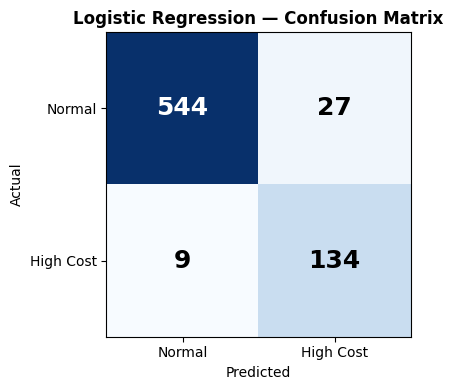

In [13]:
# === LR — Confusion Matrix ===
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_lr, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix', 
             fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['Normal', 'High Cost'])
ax.set_yticklabels(['Normal', 'High Cost'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_lr[i,j], ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm_lr[i,j] > cm_lr.max()/2 
                else 'black')
plt.tight_layout()
plt.savefig('../results/lr_cm.png', dpi=150, bbox_inches='tight')
plt.show()

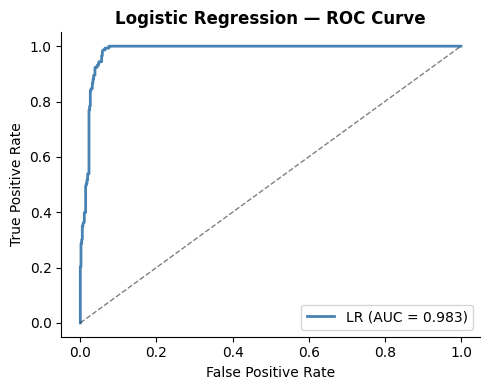

In [14]:
# === LR — ROC Curve ===
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr_lr, tpr_lr, color='steelblue', lw=2,
        label=f'LR (AUC = {auc_lr:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_title('Logistic Regression — ROC Curve', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/lr_roc.png', dpi=150, bbox_inches='tight')
plt.show()

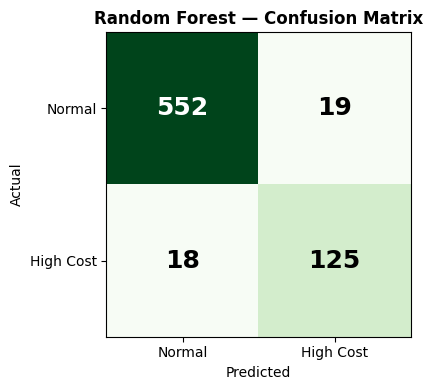

In [15]:
# === RF — Confusion Matrix ===
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_rf, cmap='Greens')
ax.set_title('Random Forest — Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['Normal', 'High Cost'])
ax.set_yticklabels(['Normal', 'High Cost'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_rf[i,j], ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm_rf[i,j] > cm_rf.max()/2 
                else 'black')
plt.tight_layout()
plt.savefig('../results/rf_cm.png', dpi=150, bbox_inches='tight')
plt.show()

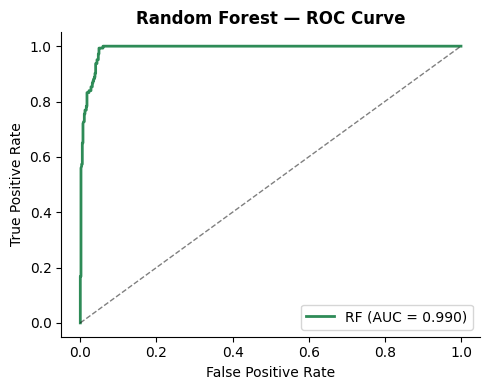

In [16]:
# === RF — ROC Curve ===
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr_rf, tpr_rf, color='seagreen', lw=2,
        label=f'RF (AUC = {auc_rf:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_title('Random Forest — ROC Curve', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/rf_roc.png', dpi=150, bbox_inches='tight')
plt.show()

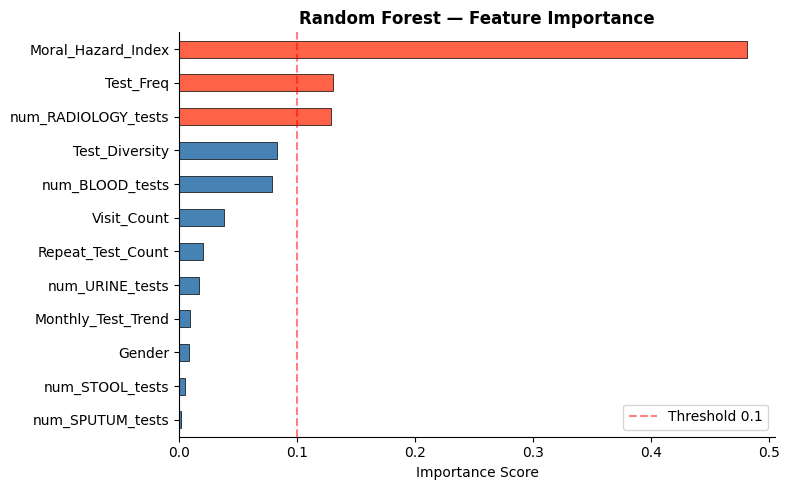

In [17]:
# === RF — Feature Importance ===
feat_imp = pd.Series(best_rf.feature_importances_,
                     index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_fi = ['tomato' if v > 0.1 else 'steelblue' 
             for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors_fi,
              edgecolor='black', linewidth=0.5)
ax.set_title('Random Forest — Feature Importance', 
             fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(x=0.1, color='red', linestyle='--', 
           alpha=0.5, label='Threshold 0.1')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/rf_feature_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()

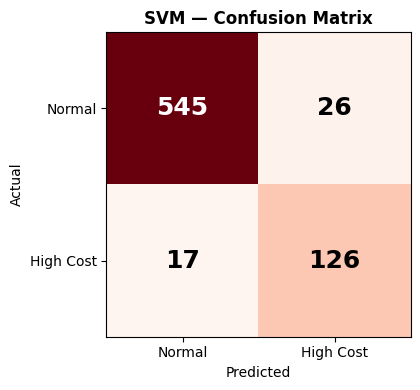

In [18]:
# === SVM — Confusion Matrix ===
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm_svm, cmap='Reds')
ax.set_title('SVM — Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['Normal', 'High Cost'])
ax.set_yticklabels(['Normal', 'High Cost'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_svm[i,j], ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm_svm[i,j] > cm_svm.max()/2 
                else 'black')
plt.tight_layout()
plt.savefig('../results/svm_cm.png', dpi=150, bbox_inches='tight')
plt.show()

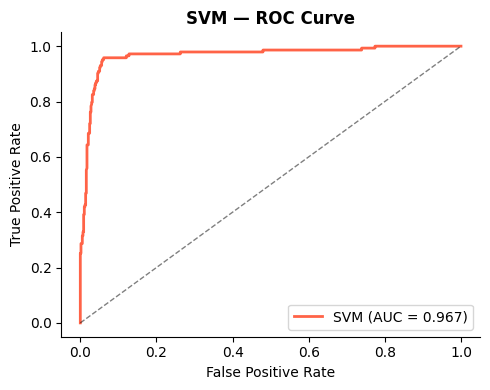

In [19]:
# === SVM — ROC Curve ===
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr_svm, tpr_svm, color='tomato', lw=2,
        label=f'SVM (AUC = {auc_svm:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_title('SVM — ROC Curve', fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/svm_roc.png', dpi=150, bbox_inches='tight')
plt.show()